# Dataset Analysis

In [15]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [16]:
def random_dataset_df(dataset_folder):
    date_dict = {}
    species_dict = {}
    for date in os.listdir(dataset_folder):
        # if date != '2024-01-06': continue
        date_folder = os.path.join(dataset_folder, date)
        for species in os.listdir(date_folder):
            species_folder = os.path.join(date_folder, species)
            for fish_type in os.listdir(species_folder):
                fish_type_folder = os.path.join(species_folder, fish_type)
                if not os.path.isdir(fish_type_folder): continue
                if 'Misclassified' in os.listdir(fish_type_folder):
                    misclassied_folder = os.path.join(fish_type_folder, 'Misclassified')
                    misclassied_count = len(os.listdir(misclassied_folder))
                    if date not in date_dict:
                        date_dict[date] = misclassied_count
                    else:
                        date_dict[date] = date_dict[date]+misclassied_count
                    if species not in species_dict:
                        species_dict[species] = misclassied_count
                    else:
                        species_dict[species] = species_dict[species]+misclassied_count
    # Sort the dictionary based on keys
    species_dict = dict(sorted(species_dict.items()))
    date_dict = dict(sorted(date_dict.items()))
    return date_dict, species_dict

In [17]:
s3_dd, s3_sd = random_dataset_df(r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\S3 Daily Data")
man_dd, ma_sd = random_dataset_df(r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\Manual Data")

In [18]:
from collections import Counter
d = dict(Counter(s3_dd) + Counter(man_dd))
s = dict(Counter(s3_sd) + Counter(ma_sd))

In [19]:
date_df = pd.DataFrame(list(d.items()), columns=['Date', 'Value'])
species_df = pd.DataFrame(list(s.items()), columns=['Species', 'Value'])

In [20]:
date_df

,Date,Value
0,2023-05-23,13
1,2023-05-25,1
2,2023-05-28,9
3,2023-05-30,2
4,2023-06-01,1
...,...,...
80,2024-02-02,37
81,2024-02-07,6
82,2024-02-10,1
83,2024-02-22,7


In [21]:
species_df

,Species,Value
0,Barracuda,7
1,Black pomfret,35
2,Blue crab,3
3,Croaker,26
4,Emperor,7
5,Indian salmon,8
6,Lady,17
7,Mackerel,12
8,Mullet,23
9,Pink perch,75


In [22]:
def plot_misclassified(my_dict, date_wise=None, species_wise=None):
    # Extract keys and values for plotting
    dates = list(my_dict.keys())
    values = list(my_dict.values())

    # Plotting 
    plt.figure(figsize=(20,10))
    
    if species_wise: 
        plt.bar(dates, values, color='red')
        plt.title(f'Misclassified images per species  {len(dates)} species')
        plt.xlabel('Species')

    if date_wise:
        plt.plot(dates, values, '.-', color='red')
        plt.title(f'Misclassified images in data collection  {len(dates)} days')
        plt.xlabel('Dates')

    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

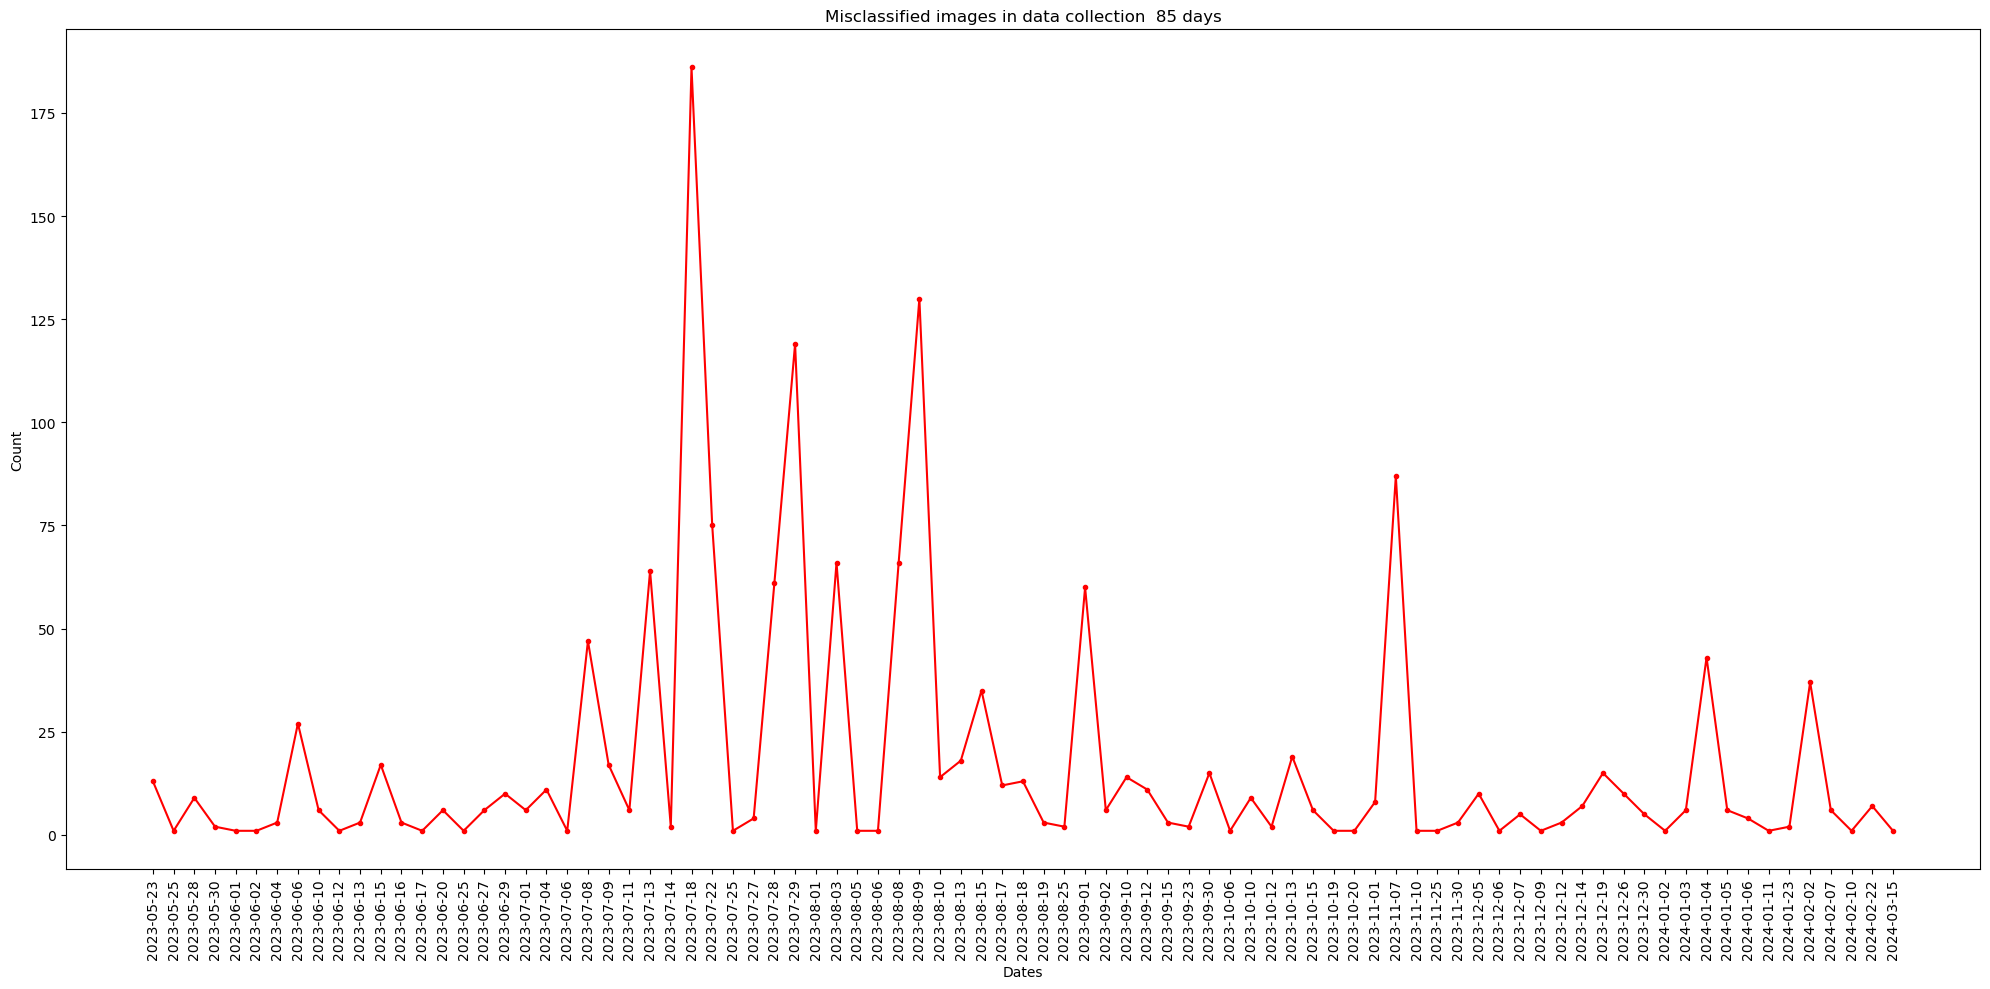

In [23]:
plot_misclassified(d, date_wise=True, species_wise=None)

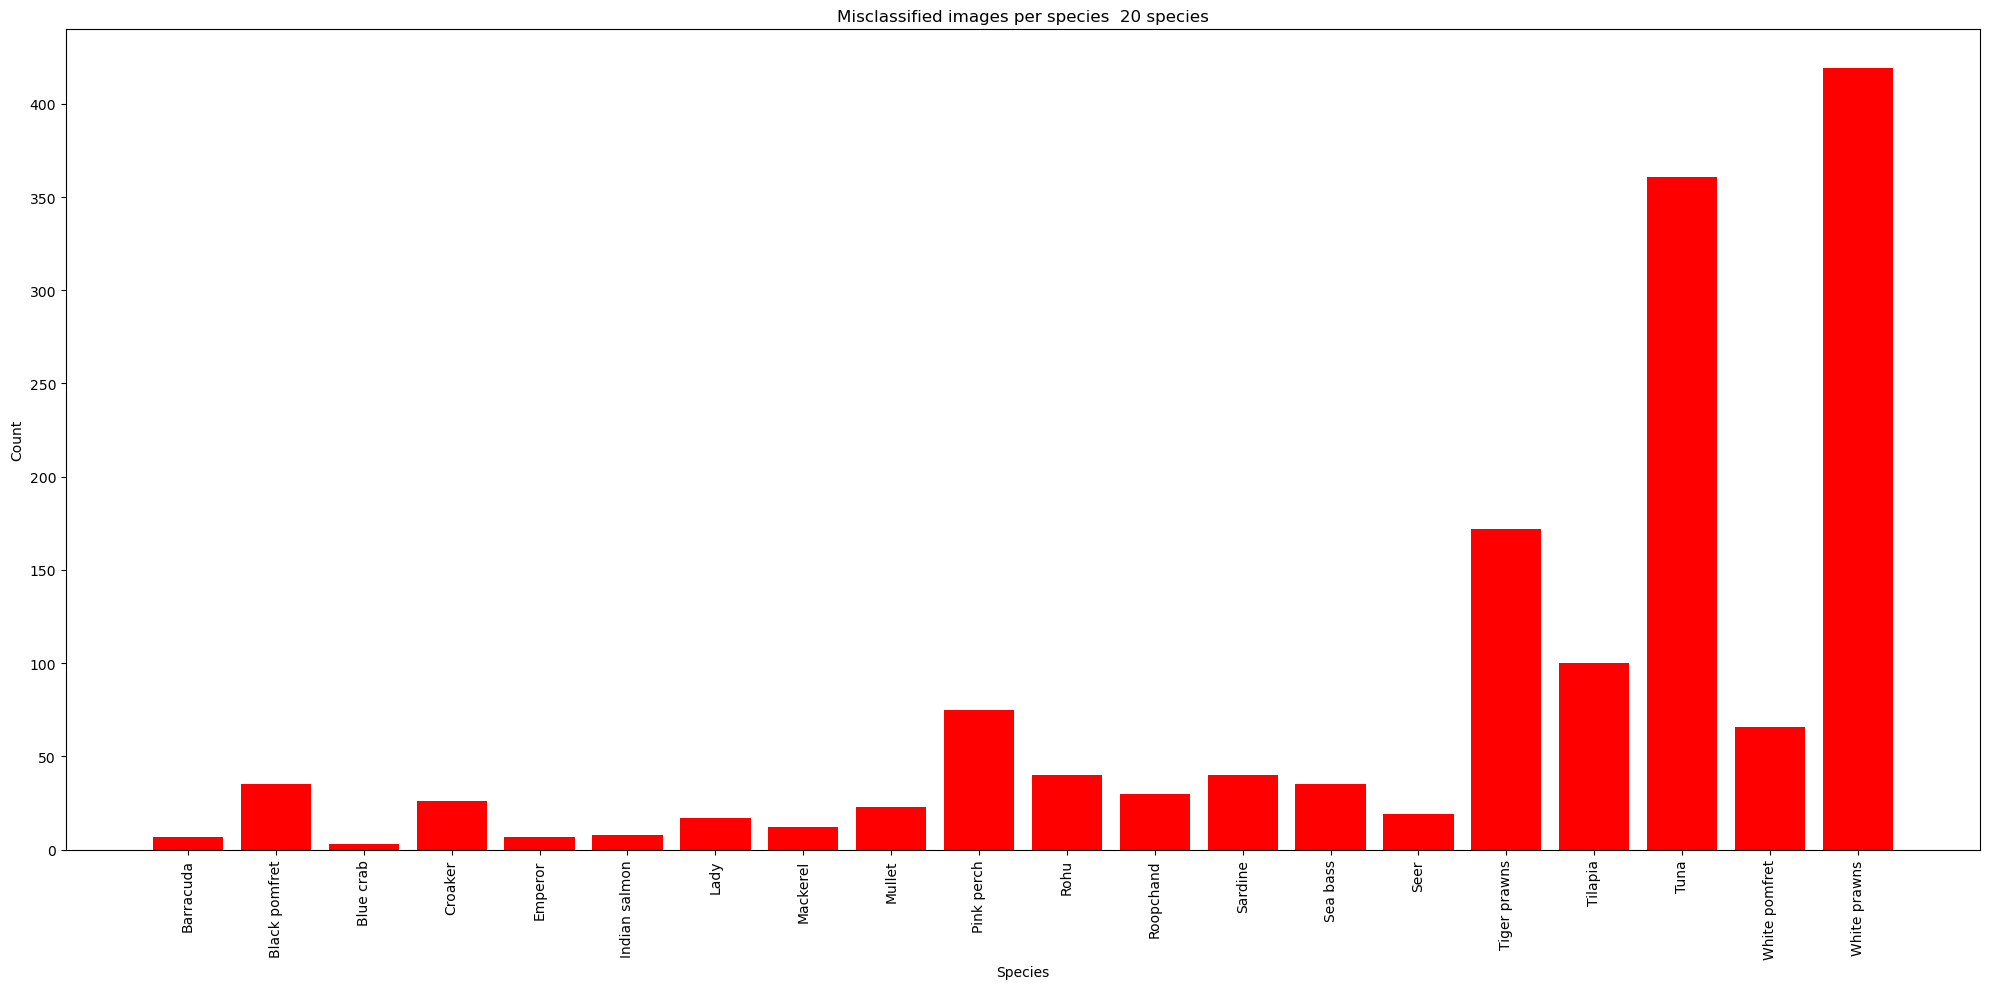

In [24]:
plot_misclassified(s, date_wise=None, species_wise=True)

In [25]:
def species_dataset_df(dataset_folder, excel_file_path):
    species_dict = {}
    fish_type_list = ['Good', 'Bad', 'Misclassified']
    for species in os.listdir(dataset_folder):
        # if species!='Barracuda': continue
        species_folder = os.path.join(dataset_folder, species)
        if not os.path.isdir(species_folder): continue
        fish_type_dict = {}
        for fish_type in tqdm(os.listdir(species_folder),
                              desc=f'Loading {species} data '):
            if fish_type not in fish_type_list: continue
            fish_type_folder = os.path.join(species_folder, fish_type)
            if not os.path.isdir(fish_type_folder): continue
            for imgfolder in os.listdir(fish_type_folder):
                imgfolder_path = os.path.join(fish_type_folder, imgfolder)

                if os.path.isdir(imgfolder_path): 
                    fish_type_count = len(os.listdir(imgfolder_path))
                    fish_type_dict[f'{fish_type}_{imgfolder}'] = fish_type_count
                else:
                    # Misclassified folder
                    fish_type_count = len(os.listdir(fish_type_folder))
                    fish_type_dict[fish_type] = fish_type_count
 
        species_dict[species.capitalize()] = fish_type_dict
    
    df = pd.DataFrame.from_dict(species_dict, orient='index').fillna(0).astype(int)
    df.sort_index(inplace=True)
    # Reorder columns
    df = df[['Good_Single', 'Good_Group', 'Bad_Single', 'Bad_Group', 'Misclassified']]
    # Add new columns
    df['Single'] = df['Good_Single'] + df['Bad_Single']
    df['Group'] = df['Good_Group'] + df['Bad_Group']
    df['Good'] = df['Good_Single'] + df['Good_Group']
    df['Bad'] = df['Bad_Single'] + df['Bad_Group']
    df.to_excel(excel_file_path, index=True)
    return df

In [26]:
# Species-wise data folder
dataset_folder = r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\Final Data"
excel_file_path = r"C:\Users\sowmy\Downloads\QzenseLabs\Dataset EDA\Dataset_distribution.xlsx"
df = species_dataset_df(dataset_folder, excel_file_path)
df

Loading White snapar data : 100%|██████████| 1/1 [00:00<00:00, 466.55it/s]


,Good_Single,Good_Group,Bad_Single,Bad_Group,Misclassified,Single,Group,Good,Bad
Are,7,0,0,0,0,7,0,7,0
Barracuda,331,8,25,2,7,356,10,339,27
Basa,270,5,10,0,0,280,5,275,10
Bata,6,0,0,0,0,6,0,6,0
Black pomfret,592,3,1,0,35,593,3,595,1
Blue crab,590,107,0,1,3,590,108,697,1
Bolo,4,1,0,0,0,4,1,5,0
Boti macha,10,0,0,0,0,10,0,10,0
Catla,302,0,20,0,0,322,0,302,20
Chara pona,9,0,0,0,0,9,0,9,0


In [27]:
class EDA:
    def __init__(self, df):
        self.df = df

    def display_counts(self):
        # Calculate the counts
        self.total_count = self.df.sum().sum()
        print("Total images Count:", self.total_count)
        try:
            self.good_count = self.df['Good'].sum()
            print("Total Good images Count:", self.good_count)
        except:
            self.good_count = 0
            print("Total Good images Count:", self.good_count)
        try:
            self.bad_count = self.df['Bad'].sum()
            print("Total Bad images Count:", self.bad_count)
        except:
            self.bad_count = 0
            print("Total Bad images Count:", self.bad_count)
        try:
            self.misclassified_count = self.df['Misclassified'].sum()
            print("Total Misclassified images Count:", self.misclassified_count)
        except:
            self.misclassified_count = 0
            print("Total Misclassified images Count:", self.misclassified_count)
            
        print("Total trainable images Count:", self.good_count + self.bad_count, "\n")
        
        self.species_count = self.df.shape[0]
        if 'Demo' in self.df.index:
            self.species_count = self.species_count-1 
        if 'Other' in self.df.index:
            self.species_count = self.species_count-1            
        print("Total Number of Species:", self.species_count, "\n")

    def plot_data(self, start_date='', end_date=''):
        self.display_counts()

        # Set the figure size
        plt.figure(figsize=(16,10))

        # Get the indices for x-axis
        x = np.arange(len(self.df.index))

        # Set the width of the bars
        bar_width = 0.40

        # Plot the bars for each column
        if self.good_count>0:
            plt.bar(x, self.df['Good'], width=bar_width, label='Good')
        if self.bad_count>0:
            plt.bar(x + bar_width, self.df['Bad'], width=bar_width, label='Bad')

        if start_date=='': 
            t='All Dates'
        else:
            if end_date=='':
                t=f'{start_date}'
            else:
                t=f'{start_date} to {end_date}'
                
        plt.xticks(x, self.df.index)
        plt.xlabel('Species')
        plt.ylabel('Images Count')
        plt.title(t+f'  ({self.species_count}) Species Dataset')
        
        plt.legend()
        plt.xticks(rotation=90)
        plt.show()

Total images Count: 171849
Total Good images Count: 37044
Total Bad images Count: 19743
Total Misclassified images Count: 1488
Total trainable images Count: 56787 

Total Number of Species: 43 



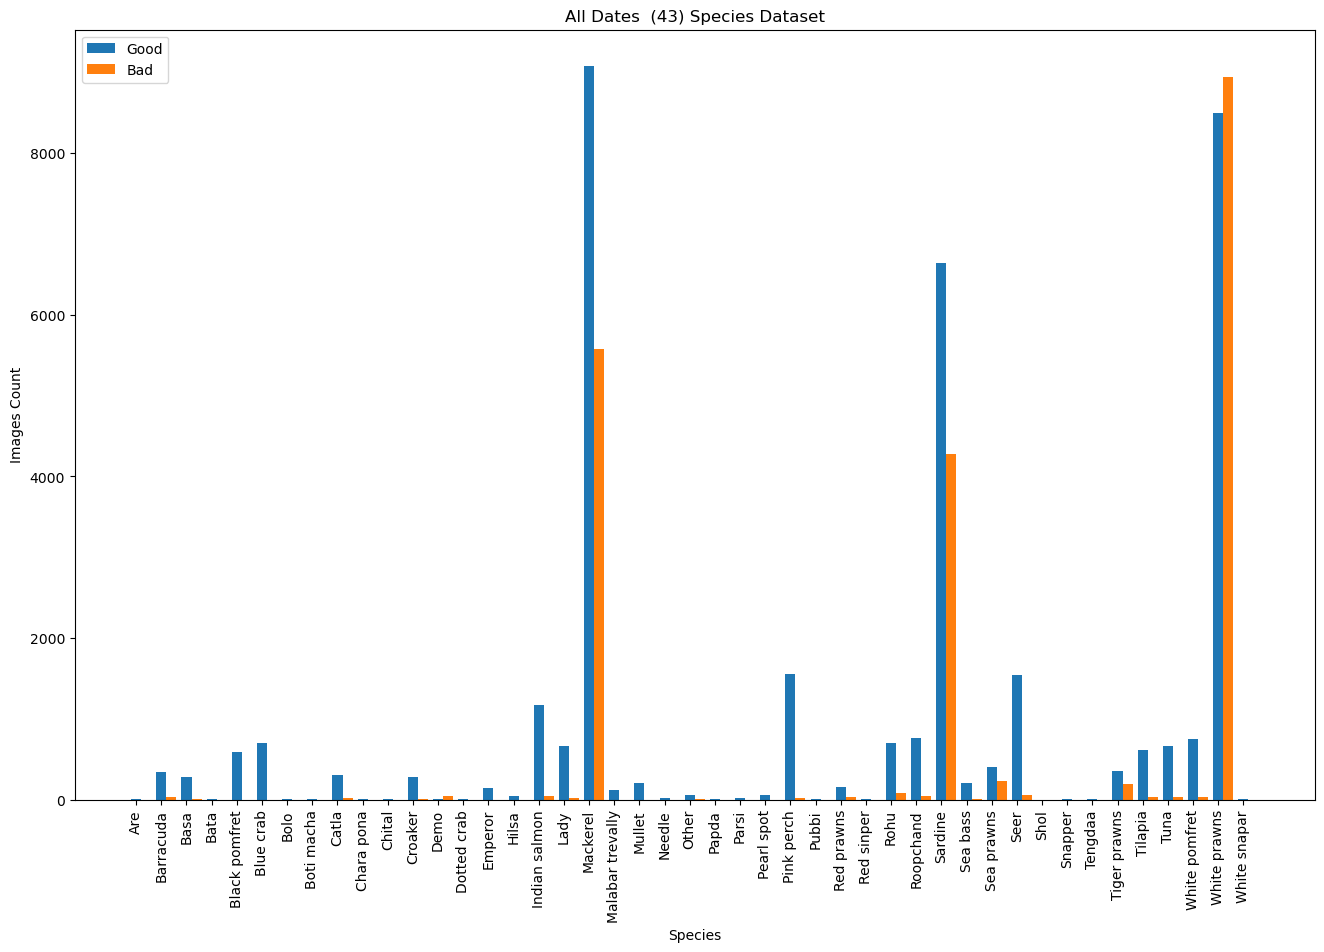

In [28]:
EDA(df).plot_data()

# Day-wise data of each species

In [29]:
class daywise_dataset_df:
    def __init__(self, dataset_folder, specific_date='',
                between_two_dates=False, start_date='', end_date=''):
        self.dataset_folder = dataset_folder
        self.specific_date = specific_date
        self.between_two_dates=between_two_dates
        self.start_date = start_date
        self.end_date=end_date

    def get_dates_list(self):
        dates_list = []
        if self.specific_date!='':
            dates_list.append(self.specific_date)
            return dates_list
        if self.between_two_dates:
            if (self.start_date!='') and (self.end_date!=''):
                for date in os.listdir(self.dataset_folder):
                    if not (start_date <= date <= end_date): continue
                    dates_list.append(date)
                return dates_list

    def get_datewise_df(self):
        fish_type_list = ['Good', 'Bad']
        dates_list = self.get_dates_list()
        species_dict_list = []
        species_dates_dict = {}
        for date in dates_list:
            date_folder = os.path.join(self.dataset_folder, date)
            species_dict = {}
            for species in os.listdir(date_folder):
                if species not in species_dates_dict:
                    species_dates_dict[species] = [date]
                else:
                    species_dates_dict[species].append(date)
                species_folder = os.path.join(date_folder, species)
                if not os.path.isdir(species_folder): continue
                
                fish_type_dict = {}
                for fish_type in tqdm(os.listdir(species_folder),
                                      desc=f'Loading {species} data '):
                    if fish_type not in fish_type_list: continue
                    fish_type_folder = os.path.join(species_folder, fish_type)
                    if not os.path.isdir(fish_type_folder): continue
                    for imgfolder in os.listdir(fish_type_folder):
                        imgfolder_path = os.path.join(fish_type_folder, imgfolder)
                        if os.path.isdir(imgfolder_path):
                            fish_type_count = len(os.listdir(imgfolder_path))
                            fish_type_dict[f'{fish_type}_{imgfolder}'] = fish_type_count
                species_dict[species.capitalize()] = fish_type_dict
            species_dict_list.append(species_dict)
        return species_dict_list, species_dates_dict


    def add_columns(self, df):
        df.sort_index(inplace=True)
        df['Good'] = df.get('Good_Single', 0) + df.get('Good_Group', 0)
        df['Bad'] = df.get('Bad_Single', 0) + df.get('Bad_Group', 0)
        df['Misclassified'] = df.get('Good_Misclassified', 0) + df.get('Bad_Misclassified', 0)
        if 'Good_Misclassified' in df.columns:
            df.drop(columns=['Good_Misclassified'], inplace=True)
        if 'Bad_Misclassified' in df.columns:
            df.drop(columns=['Bad_Misclassified'], inplace=True)
        if (df['Misclassified'] == 0).all():
            df.drop(columns=['Misclassified'], inplace=True)
        df = df.reindex(sorted(df.columns), axis=1)
        return df
        
    def get_df(self):
        if self.specific_date!='':
            species_dict, species_dates_dict = self.get_datewise_df()
            df = pd.DataFrame.from_dict(species_dict[0], orient='index').fillna(0).astype(int)
            df = self.add_columns(df)
            return df, species_dates_dict
        
        elif self.between_two_dates and (self.start_date!='') and (self.end_date!=''):
            from collections import defaultdict
            species_dict_list, species_dates_dict = self.get_datewise_df()
            combined_df = defaultdict(lambda: defaultdict(int))
            for dataframe in species_dict_list:
                for key, sub_dict in dataframe.items():
                    for sub_key, value in sub_dict.items():
                        combined_df[key][sub_key] += value
            combined_df = pd.DataFrame.from_dict(combined_df, orient='index').fillna(0).astype(int)
            combined_df.sort_index(inplace=True)
            combined_df = self.add_columns(combined_df)
            return combined_df, species_dates_dict

# Specific date dataset

In [31]:
specific_date = '2024-03-22'
dataset_folder = r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\S3 Daily Data"
obj = daywise_dataset_df(dataset_folder=dataset_folder,
                         specific_date=specific_date)
df, _ = obj.get_df()
df

Loading White prawns data : 100%|██████████| 1/1 [00:00<00:00, 393.17it/s]


,Bad,Bad_Group,Bad_Single,Good,Good_Single
Indian salmon,0,0,0,91,91
Mackerel,7,0,7,16,16
Tuna,0,0,0,79,79
White prawns,185,3,182,0,0


Total images Count: 756
Total Good images Count: 186
Total Bad images Count: 192
Total Misclassified images Count: 0
Total trainable images Count: 378 

Total Number of Species: 4 



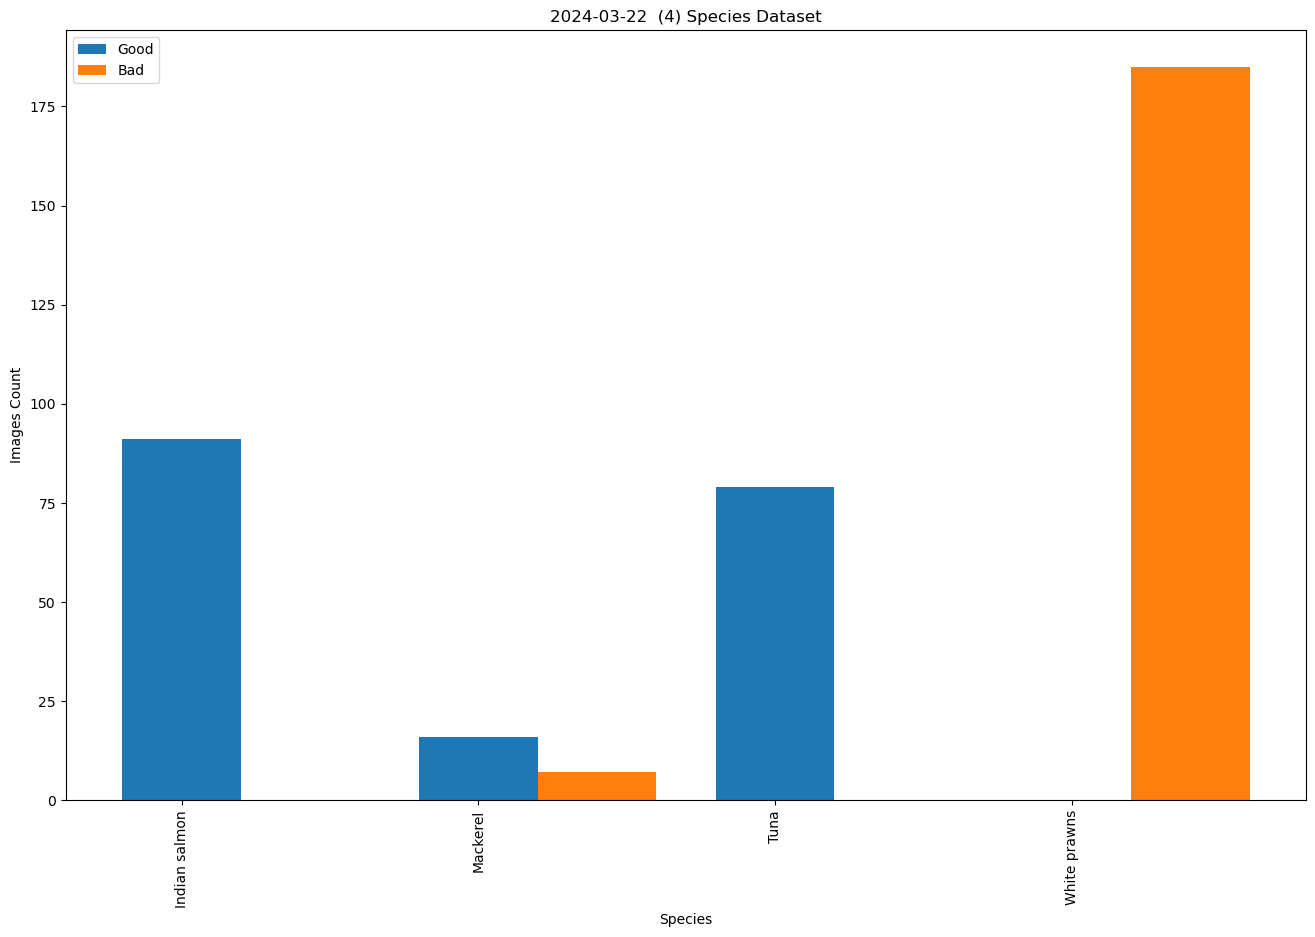

In [32]:
EDA(df).plot_data(start_date=specific_date)

# Data between any two dates of each species

In [33]:
start_date = '2024-03-15'
end_date = '2024-03-25'
dataset_folder = r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\S3 Daily Data"
obj = daywise_dataset_df(dataset_folder=dataset_folder,
                         between_two_dates=True, start_date=start_date, end_date=end_date)
df, species_dates_dict = obj.get_df()
df

Loading White prawns data : 100%|██████████| 1/1 [00:00<?, ?it/s]


,Bad,Bad_Group,Bad_Single,Good,Good_Group,Good_Single,Misclassified
Barracuda,7,0,7,0,0,0,0
Black pomfret,0,0,0,20,0,20,0
Blue crab,0,0,0,10,0,10,0
Indian salmon,0,0,0,190,0,190,0
Mackerel,350,0,350,244,0,244,0
Pink perch,0,0,0,27,0,27,0
Sardine,222,0,222,339,0,339,0
Seer,0,0,0,35,0,35,0
Tuna,0,0,0,161,0,161,1
White pomfret,0,0,0,31,0,31,0


Total images Count: 5277
Total Good images Count: 1278
Total Bad images Count: 1360
Total Misclassified images Count: 1
Total trainable images Count: 2638 

Total Number of Species: 11 



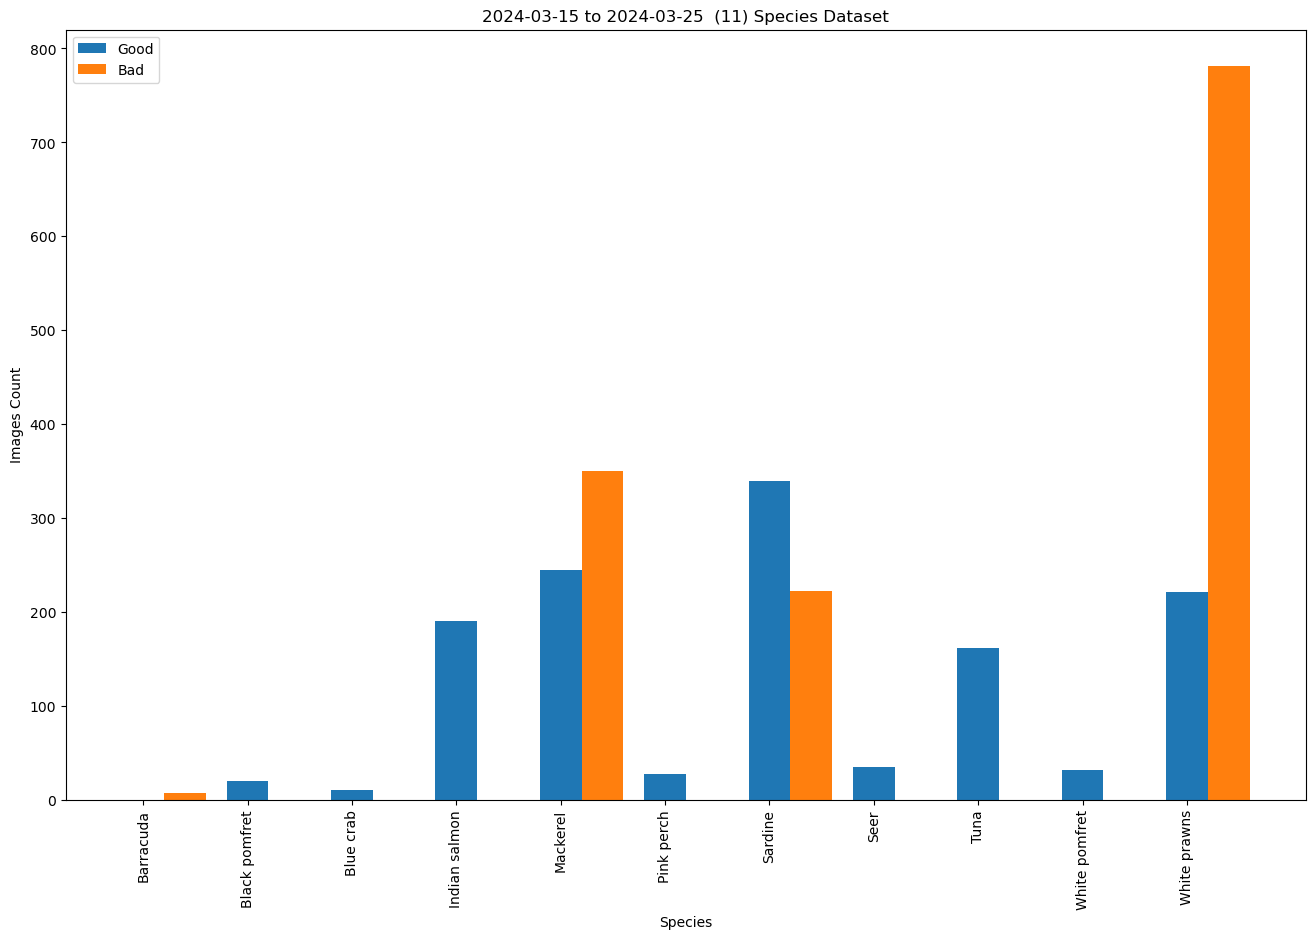

In [34]:
EDA(df).plot_data(start_date, end_date)

In [67]:
# Create a DataFrame
new_df = pd.DataFrame(list(species_dates_dict.items()), columns=['Species', 'Dates'])

# Add a column for the total number of dates
new_df['Total Dates'] = new_df['Dates'].apply(lambda x: len(x))
new_df

,Species,Dates,Total Dates
0,Barracuda,"[2023-06-01, 2023-06-02]",2
1,Basa,"[2023-06-01, 2023-06-02, 2023-06-03]",3
2,Catla,"[2023-06-01, 2023-06-02, 2023-06-03]",3
3,Emperor,[2023-06-01],1
4,Indian salmon,"[2023-06-01, 2023-06-02]",2
5,Mackerel,"[2023-06-01, 2023-06-02]",2
6,Pink perch,"[2023-06-01, 2023-06-02, 2023-06-03, 2023-06-04]",4
7,Rohu,"[2023-06-01, 2023-06-02, 2023-06-03]",3
8,Roopchand,"[2023-06-01, 2023-06-02, 2023-06-03, 2023-06-04]",4
9,Sardine,"[2023-06-01, 2023-06-02, 2023-06-03, 2023-06-04]",4


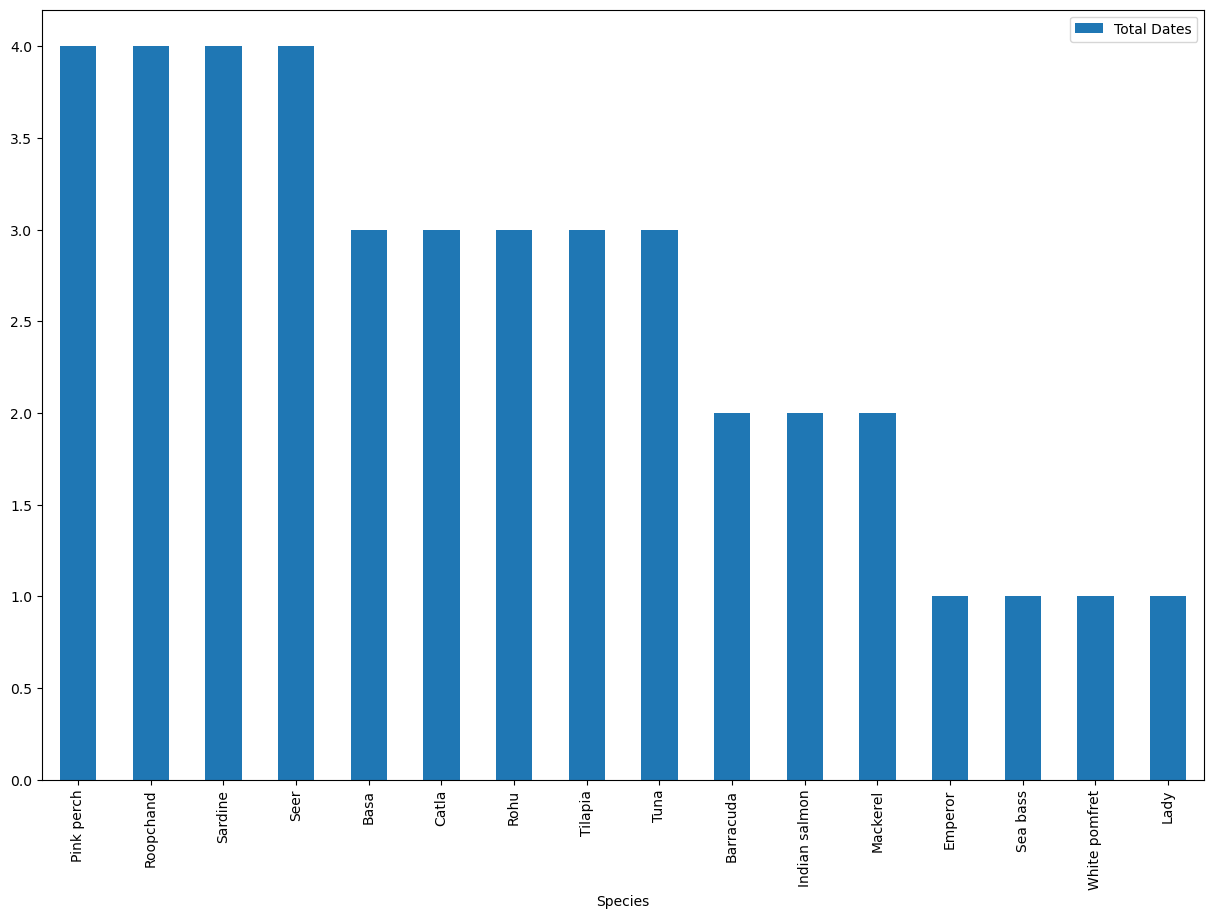

In [68]:
# sort the plot data
new_df.sort_values(by='Total Dates', ascending=False).plot(kind='bar', 
                                                           x='Species', 
                                                           y='Total Dates', 
                                                           figsize=(15, 10),
                                                           xlabel='Species');

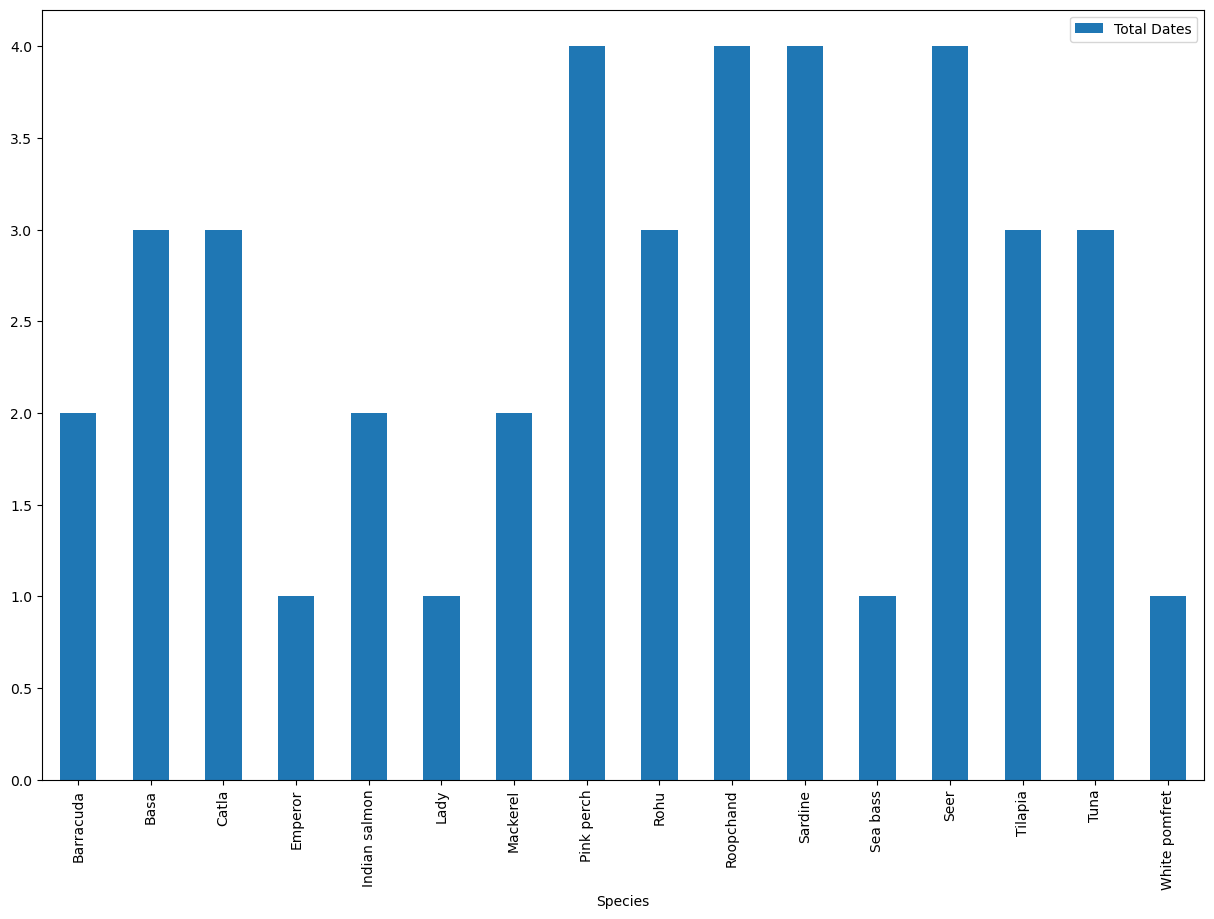

In [69]:
# sort the plot data alphabetically
new_df.sort_values(by='Species', ascending=True).plot(kind='bar', 
                                                      x='Species', 
                                                      y='Total Dates', 
                                                      figsize=(15, 10),
                                                      xlabel='Species');